In [1]:
# Import dependencies
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.interpolate import interp1d
import random
from shapely.geometry import Point
import pickle
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point, Polygon

pd.set_option('display.max_columns', None)

## Change working directory
os.chdir('../..')

In [2]:
# Read plot data with polygons
plot_poly = gpd.read_file('Covariate_and_metaregressor_processing/Input_data/unit_polygons.shp')

# Consistent lat/lon for all units
plot_poly['Latitude'] = plot_poly.centroid.y
plot_poly['Longitude'] = plot_poly.centroid.x

plot_poly

/tmp/ipykernel_1071240/4074121640.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  plot_poly['Latitude'] = plot_poly.centroid.y
/tmp/ipykernel_1071240/4074121640.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  plot_poly['Longitude'] = plot_poly.centroid.x


,PlotID,Latitude,Longitude,Site,UnitID,UniqueID,geometry
0,FFS7CONTROL,36.581771,-118.762344,Sequoia,FFS7CONTROL,Sequoia_FFS_FFS7CONTROL,"POLYGON ((-118.76289 36.58132, -118.76291 36.5..."
1,FFS5BURN,36.585279,-118.754700,Sequoia,FFS5BURN,Sequoia_FFS_FFS5BURN,"POLYGON ((-118.75524 36.58482, -118.75526 36.5..."
2,FFS6BURN,36.585635,-118.759024,Sequoia,FFS6BURN,Sequoia_FFS_FFS6BURN,"POLYGON ((-118.75955 36.58519, -118.75957 36.5..."
3,FFS2BURN,36.595484,-118.746431,Sequoia,FFS2BURN,Sequoia_FFS_FFS2BURN,"POLYGON ((-118.74697 36.59503, -118.74699 36.5..."
4,LOTHAR,36.562389,-118.741997,TharpsCreek,LOTHAR,Sequoia_Tharp_LOTHAR,"POLYGON ((-118.74257 36.56191, -118.74259 36.5..."
...,...,...,...,...,...,...,...
89,20,38.180488,-119.986097,STEF,20,STEF-VDT_20,"POLYGON ((-119.98716 38.18014, -119.98717 38.1..."
90,21,38.180718,-119.983347,STEF,21,STEF-VDT_21,"POLYGON ((-119.98398 38.18063, -119.98407 38.1..."
91,22,38.178893,-119.985330,STEF,22,STEF-VDT_22,"POLYGON ((-119.98562 38.17851, -119.98576 38.1..."
92,23,38.177163,-119.984951,STEF,23,STEF-VDT_23,"POLYGON ((-119.98561 38.17687, -119.98572 38.1..."


# Download data from Web Soil Service

Upload a shapefile containing the polygons of each treatment unit to the SSURGO web soil survey (https://websoilsurvey.nrcs.usda.gov/app/) as the area of interest (AOI). Then download the soils data as a zipfile and save the unzipped data in the folder Covariate_and_metaregressor_processing/Input_data/SSURGO_datafiles. This step happens outside of this Jupyter notebook.

In [8]:
## Name of file downloaded and unzipped from WSS
wss_fn = 'wss_aoi_2026-01-02_09-45-04'

# Process SSURGO data

In [4]:
def extract_ssurgo_shp(folder, 
                       soil_dir = 'Covariate_and_metaregressor_processing/Input_data/SSURGO_datafiles', 
                       spatial_dir = 'spatial/'):
  '''Loads shapefiles from a downloaded SSURGO AOI query'''
  flpth = Path(soil_dir, folder, spatial_dir)
  aoi = gpd.read_file(Path(flpth, 'aoi_a_aoi.shp'))
  soilmu_a = gpd.read_file(Path(flpth, 'soilmu_a_aoi.shp'))
  soilmu_l = gpd.read_file(Path(flpth, 'soilmu_l_aoi.shp'))
  soilmu_p = gpd.read_file(Path(flpth, 'soilmu_p_aoi.shp'))
  soilsf_l = gpd.read_file(Path(flpth, 'soilsf_l_aoi.shp'))
  soilsf_p = gpd.read_file(Path(flpth, 'soilsf_p_aoi.shp'))
  for d, n in zip([aoi, soilmu_a, soilmu_l, soilmu_p, soilsf_l, soilsf_p],
                  ['aoi', 'soilmu_a', 'soilmu_l', 'soilmu_p', 'soilsf_l', 'soilsf_p']):
    if len(d) == 0:
      print("No entries in {}".format(n))
  return aoi, soilmu_a, soilmu_l, soilmu_p, soilsf_l, soilsf_p

In [9]:
## Extract soils data from SSURGO download
aoi, soilmu, _, _, _, _ = extract_ssurgo_shp(folder = wss_fn)

No entries in soilmu_l
No entries in soilmu_p
No entries in soilsf_l
No entries in soilsf_p


In [10]:
## Check that area symbols include 'CA724', 'CA792', 'CA607', 'CA750', 'CA731', 'CA693'
soilmu['AREASYMBOL'].unique()

array(['CA750', 'CA792', 'CA724', 'CA731', 'CA607', 'CA693'], dtype=object)

In [11]:
## Associate each polygon in soilmu with a plot from plot_poly
## Logic: a soil polygon is associated with a plot if its centroid falls within the plot polygon

## Add new columns to soil dataframe
soil_df = soilmu.copy()
soil_df['Site'] = np.nan
soil_df['UnitID'] = np.nan
soil_df['unique_nm'] = np.nan

for i in soilmu.index:
  plot = plot_poly.loc[plot_poly.contains(soilmu.loc[i,'geometry'].centroid)]
  # Check that each soil polygon is associated with only one plot
  if len(plot)!=1:
    print(i)
  # soil_df.loc[i,'PlotID'] = plot.iloc[0]['PlotID']
  soil_df.loc[i,'Site'] = plot.iloc[0]['Site']
  soil_df.loc[i, 'UnitID'] = plot.iloc[0]['UnitID']
  soil_df.loc[i, 'unique_nm'] = plot.iloc[0]['UniqueID']

soil_df

/tmp/ipykernel_1071240/4037908583.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Teakettle' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  soil_df.loc[i,'Site'] = plot.iloc[0]['Site']
/tmp/ipykernel_1071240/4037908583.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'BN2' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  soil_df.loc[i, 'UnitID'] = plot.iloc[0]['UnitID']
/tmp/ipykernel_1071240/4037908583.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Teakettle_BN2' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  soil_df.loc[i, 'unique_nm'] = plot.iloc[0]['UniqueID']


49
50


,AREASYMBOL,SPATIALVER,MUSYM,MUKEY,geometry,Site,UnitID,unique_nm
0,CA750,10,148,465123,"POLYGON ((-119.01751 36.95644, -119.01769 36.9...",Teakettle,BN2,Teakettle_BN2
1,CA750,10,170,465145,"POLYGON ((-119.02518 36.95606, -119.02521 36.9...",Teakettle,UN1,Teakettle_UN1
2,CA792,5,3152,2766864,"POLYGON ((-118.74698 36.5954, -118.74699 36.59...",Sequoia,FFS2BURN,Sequoia_FFS_FFS2BURN
3,CA792,5,4131,2766871,"POLYGON ((-118.73281 36.55945, -118.73251 36.5...",TharpsCreek,UPLOG,Sequoia_Tharp_UPLOG
4,CA792,5,4145,2924639,"POLYGON ((-118.75955 36.58519, -118.75957 36.5...",Sequoia,FFS6BURN,Sequoia_FFS_FFS6BURN
...,...,...,...,...,...,...,...,...
131,CA693,4,7156,1652093,"POLYGON ((-120.15824 39.17411, -120.15885 39.1...",WLakeTahoe,TWC 3 C,UPFUb_TWC 3 C
132,CA693,4,7156,1652093,"POLYGON ((-120.1595 39.17141, -120.15954 39.17...",WLakeTahoe,TWC 3 T,UPFUb_TWC 3 T
133,CA693,4,7181,1652121,"POLYGON ((-120.19304 39.15531, -120.19483 39.1...",WLakeTahoe,WRD 20-16 T,UPFUb_WRD 20-16 T
134,CA693,4,7181,1652121,"POLYGON ((-120.1881 39.1479, -120.18812 39.147...",WLakeTahoe,WRD 20-9 C,UPFUb_WRD 20-9 C


In [12]:
## A few checks

## Check the soil survey(s) associated with each site
for s in soil_df['Site'].unique():
  print(s)
  print(soil_df.loc[soil_df['Site']==s, 'AREASYMBOL'].unique())

## Check that we don't have any null sites (i.e., orphaned soil polygons)
assert len(soil_df.loc[soil_df['unique_nm'].isnull()])==0

## Check that we didn't drop any plots
print(len(soil_df['unique_nm'].unique()), len(plot_poly['UniqueID'].unique()))

## ... if we did drop plots, which ones??
[i for i in plot_poly['UniqueID'].unique() if i not in soil_df['unique_nm'].unique()]

Teakettle
['CA750']
Sequoia
['CA792']
TharpsCreek
['CA792']
Blodgett
['CA724']
STEF
['CA731']
LaTour
['CA607']
WLakeTahoe
['CA693']
93 94


['Teakettle_BS1']

In [13]:
## All the data are here, but the plots are imperfectly matched. Need to do this step to match
soil_df = plot_poly.overlay(soil_df, how='intersection')

In [14]:
## Revise column names
soil_df.drop(columns=['Site_2', 'UnitID_2'], inplace=True)
soil_df.rename(columns={'Site_1':'Site', 'UnitID_1':'UnitID'}, inplace=True)

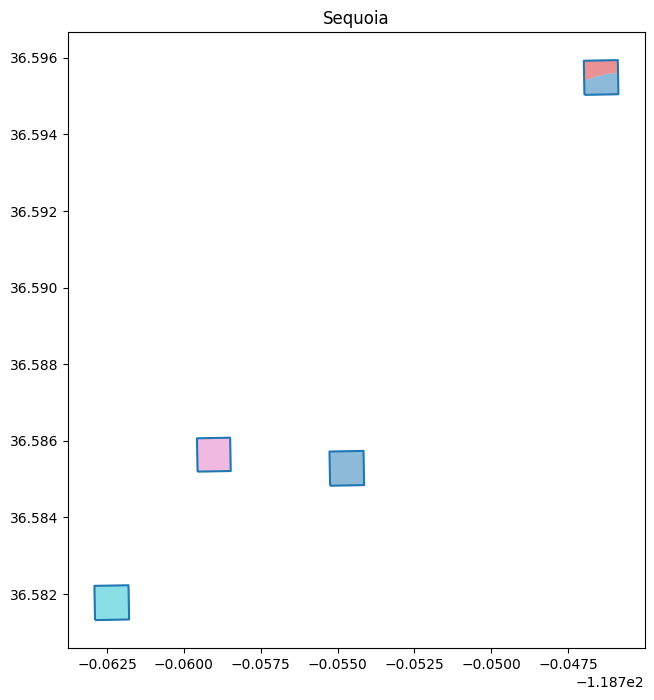

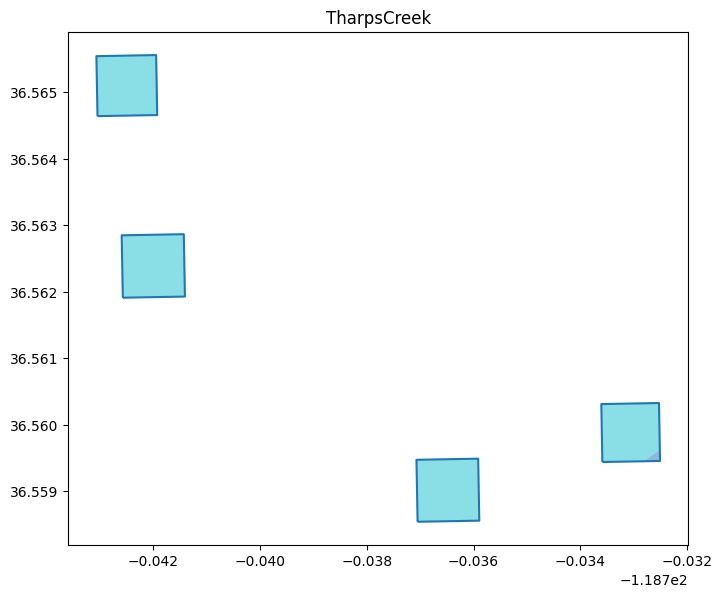

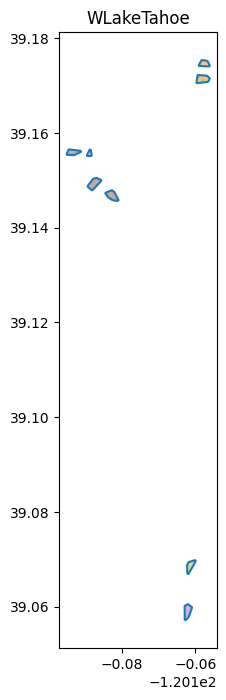

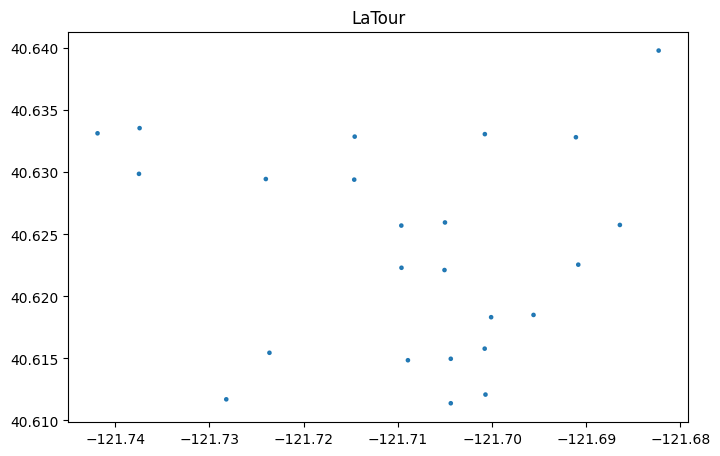

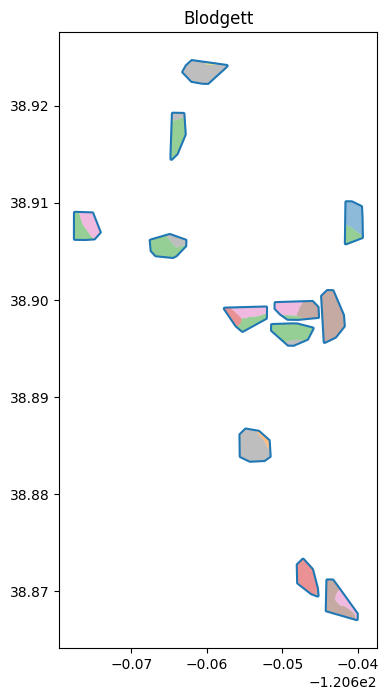

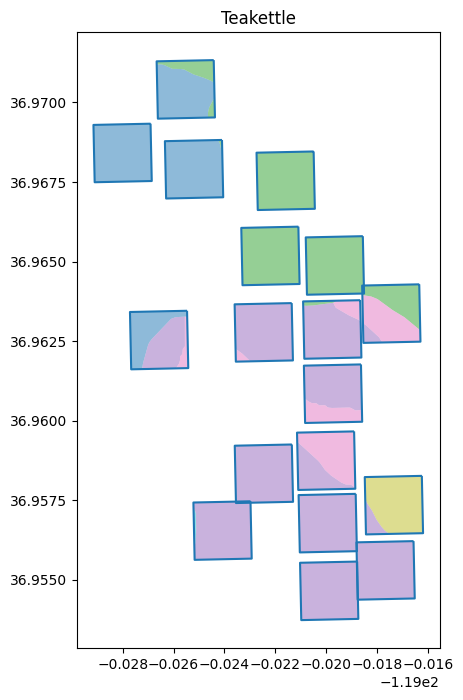

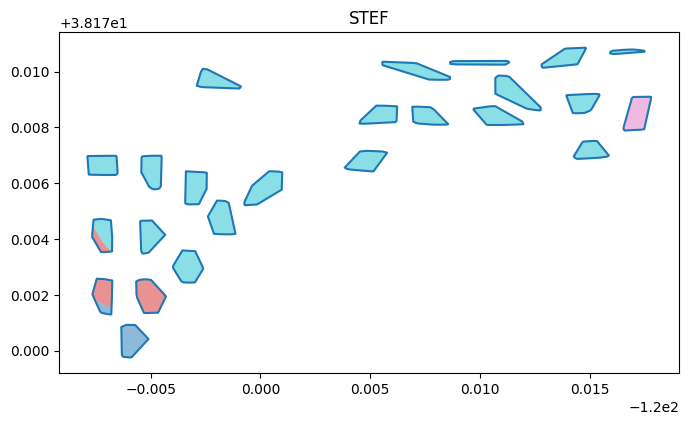

In [15]:
# Visually verify complete soil data for each site (no missing polygons)
for site in plot_poly['Site'].unique():
  fig, ax = plt.subplots(figsize = (8,8))
  plot_poly.loc[plot_poly['Site']==site].exterior.plot(ax=ax)
  soil_df.loc[soil_df['Site']==site].plot('MUKEY', ax = ax, alpha = 0.5)
  ax.set_title(site)

In [16]:
### Load SSURGO variables processed via `process_ssurgo_variables.R`

all_soils = pd.read_csv('Covariate_and_metaregressor_processing/Processed_data/Soil/all_unit_soils.csv')
all_soils

,comppct.r,compname,majcompflag,mukey,cokey,ksat,cec,awc,total_depth,musym,muname,muacres
0,4,McCarthy,No,459921,26882415,NaN,NaN,NaN,NaN,AaB,Aiken loam_2 to 9 percent slopes_low ffd,8954
1,3,Guenoc,No,459921,26882416,NaN,NaN,NaN,NaN,AaB,Aiken loam_2 to 9 percent slopes_low ffd,8954
2,8,Cohasset,No,459921,26882417,NaN,NaN,NaN,NaN,AaB,Aiken loam_2 to 9 percent slopes_low ffd,8954
3,85,Aiken,Yes,459921,26882418,10.66,11.49,0.17,230.0,AaB,Aiken loam_2 to 9 percent slopes_low ffd,8954
4,85,Aiken,Yes,459922,26882419,9.00,22.50,0.16,229.0,AaC,Aiken loam_8 to 15 percent slopes,6321
...,...,...,...,...,...,...,...,...,...,...,...,...
4541,12,Canyonview,No,3233140,26678389,81.76,11.15,0.09,155.0,5134,Littlebaugh_warm-Rock outcrop_granitic-Mororoc...,2593
4542,45,Littlebaugh,Yes,3233140,26678390,66.40,8.39,0.07,200.0,5134,Littlebaugh_warm-Rock outcrop_granitic-Mororoc...,2593
4543,15,Mororock,Yes,3233140,26678391,9.84,20.33,0.16,153.0,5134,Littlebaugh_warm-Rock outcrop_granitic-Mororoc...,2593
4544,5,Canyonview,No,3233140,26678392,92.00,5.54,0.04,150.0,5134,Littlebaugh_warm-Rock outcrop_granitic-Mororoc...,2593


In [17]:
def weight_soil_var(df, mu, var):
  '''Finds the weighted average of a soil variable (var) within a mapunit (mu) based on the percent of mapunit associated with a component.'''
  '''Make sure to use mukey and not musym'''
  mu_df = df.loc[df['mukey']==mu]
  mu_df = mu_df.loc[mu_df[var].isnull()==False]
  return (mu_df[var] * mu_df['comppct.r']).sum()/mu_df['comppct.r'].sum()

def soil_property_dict(df, var):
  '''Loops through all mapunits (mu) and associates a weighted average soil variable (var) with each.'''
  d = dict()
  for i in df['mukey'].unique():
    tmp = df.loc[df['mukey']==i]
    d[str(i)] = weight_soil_var(tmp, i, var)
  return d

In [18]:
### Make dictionaries of weighted average values for each map unit for CEC, depth, and AWS variables
cec_dict = soil_property_dict(all_soils, 'cec')
depth_dict = soil_property_dict(all_soils, 'total_depth')
awc_dict = soil_property_dict(all_soils, 'awc')
ksat_dict = soil_property_dict(all_soils, 'ksat')

/tmp/ipykernel_1071240/1084334451.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (mu_df[var] * mu_df['comppct.r']).sum()/mu_df['comppct.r'].sum()


In [19]:
### Merge weighted average values into soil_df
soil_df['TotalDepth'] = [depth_dict[i] for i in soil_df['MUKEY']]
soil_df['CEC_50cm'] = [cec_dict[i] for i in soil_df['MUKEY']]
soil_df['ksat_50cm'] =  [ksat_dict[i] for i in soil_df['MUKEY']]
soil_df['AWC_50cm'] =  [awc_dict[i] for i in soil_df['MUKEY']]
soil_df

,PlotID,Latitude,Longitude,Site,UnitID,UniqueID,AREASYMBOL,SPATIALVER,MUSYM,MUKEY,unique_nm,geometry,TotalDepth,CEC_50cm,ksat_50cm,AWC_50cm
0,FFS7CONTROL,36.581771,-118.762344,Sequoia,FFS7CONTROL,Sequoia_FFS_FFS7CONTROL,CA792,5,4148,2924647,Sequoia_FFS_FFS7CONTROL,"POLYGON ((-118.76291 36.58221, -118.7618 36.58...",191.836735,14.350000,72.216429,0.105510
1,FFS5BURN,36.585279,-118.754700,Sequoia,FFS5BURN,Sequoia_FFS_FFS5BURN,CA792,5,3141,2766861,Sequoia_FFS_FFS5BURN,"POLYGON ((-118.75526 36.58572, -118.75416 36.5...",163.842105,59.566105,89.193895,0.102211
2,FFS6BURN,36.585635,-118.759024,Sequoia,FFS6BURN,Sequoia_FFS_FFS6BURN,CA792,5,4145,2924639,Sequoia_FFS_FFS6BURN,"POLYGON ((-118.75957 36.58606, -118.75849 36.5...",190.000000,12.728947,67.866842,0.107895
3,FFS2BURN,36.595484,-118.746431,Sequoia,FFS2BURN,Sequoia_FFS_FFS2BURN,CA792,5,3152,2766864,Sequoia_FFS_FFS2BURN,"POLYGON ((-118.74699 36.59592, -118.74589 36.5...",171.368421,65.403448,100.096632,0.090737
4,FFS2BURN,36.595484,-118.746431,Sequoia,FFS2BURN,Sequoia_FFS_FFS2BURN,CA792,5,3141,2766861,Sequoia_FFS_FFS2BURN,"POLYGON ((-118.74698 36.5954, -118.74696 36.59...",163.842105,59.566105,89.193895,0.102211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,20,38.180488,-119.986097,STEF,20,STEF-VDT_20,CA731,9,198,465072,STEF-VDT_20,"POLYGON ((-119.98717 38.18019, -119.98718 38.1...",145.571429,17.797143,11.848571,0.131429
136,21,38.180718,-119.983347,STEF,21,STEF-VDT_21,CA731,9,198,465072,STEF-VDT_21,"POLYGON ((-119.98407 38.18067, -119.98403 38.1...",145.571429,17.797143,11.848571,0.131429
137,22,38.178893,-119.985330,STEF,22,STEF-VDT_22,CA731,9,198,465072,STEF-VDT_22,"POLYGON ((-119.9857 38.17851, -119.98576 38.17...",145.571429,17.797143,11.848571,0.131429
138,23,38.177163,-119.984951,STEF,23,STEF-VDT_23,CA731,9,198,465072,STEF-VDT_23,"POLYGON ((-119.98529 38.17749, -119.98527 38.1...",145.571429,17.797143,11.848571,0.131429


In [20]:
### For plots associated with multiple mapunits, I want an area-weighted average of each soil variable across the mapunits falling within the plot

## Convert to a projected reference system
soil_df = soil_df.to_crs(epsg=3310)


soil_df['area'] = soil_df.area
soil_df

,PlotID,Latitude,Longitude,Site,UnitID,UniqueID,AREASYMBOL,SPATIALVER,MUSYM,MUKEY,unique_nm,geometry,TotalDepth,CEC_50cm,ksat_50cm,AWC_50cm,area
0,FFS7CONTROL,36.581771,-118.762344,Sequoia,FFS7CONTROL,Sequoia_FFS_FFS7CONTROL,CA792,5,4148,2924647,Sequoia_FFS_FFS7CONTROL,"POLYGON ((110543.75 -158697.284, 110642.746 -1...",191.836735,14.350000,72.216429,0.105510,9839.260568
1,FFS5BURN,36.585279,-118.754700,Sequoia,FFS5BURN,Sequoia_FFS_FFS5BURN,CA792,5,3141,2766861,Sequoia_FFS_FFS5BURN,"POLYGON ((111221.648 -158298.512, 111320.55 -1...",163.842105,59.566105,89.193895,0.102211,9820.717693
2,FFS6BURN,36.585635,-118.759024,Sequoia,FFS6BURN,Sequoia_FFS_FFS6BURN,CA792,5,4145,2924639,Sequoia_FFS_FFS6BURN,"POLYGON ((110836.1 -158265.209, 110932.449 -15...",190.000000,12.728947,67.866842,0.107895,9320.170386
3,FFS2BURN,36.595484,-118.746431,Sequoia,FFS2BURN,Sequoia_FFS_FFS2BURN,CA792,5,3152,2766864,Sequoia_FFS_FFS2BURN,"POLYGON ((111945.605 -157154.821, 112044.308 -...",171.368421,65.403448,100.096632,0.090737,4431.634220
4,FFS2BURN,36.595484,-118.746431,Sequoia,FFS2BURN,Sequoia_FFS_FFS2BURN,CA792,5,3141,2766861,Sequoia_FFS_FFS2BURN,"POLYGON ((111947.412 -157212.45, 111949.379 -1...",163.842105,59.566105,89.193895,0.102211,5349.623245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,20,38.180488,-119.986097,STEF,20,STEF-VDT_20,CA731,9,198,465072,STEF-VDT_20,"POLYGON ((1122.316 18211.414, 1121.804 18214.5...",145.571429,17.797143,11.848571,0.131429,8245.146526
136,21,38.180718,-119.983347,STEF,21,STEF-VDT_21,CA731,9,198,465072,STEF-VDT_21,"POLYGON ((1393.715 18264.836, 1397.067 18270.5...",145.571429,17.797143,11.848571,0.131429,1578.928745
137,22,38.178893,-119.985330,STEF,22,STEF-VDT_22,CA731,9,198,465072,STEF-VDT_22,"POLYGON ((1251.212 18025.423, 1245.764 18025.8...",145.571429,17.797143,11.848571,0.131429,7393.989833
138,23,38.177163,-119.984951,STEF,23,STEF-VDT_23,CA731,9,198,465072,STEF-VDT_23,"POLYGON ((1287.139 17912.079, 1289.126 17912.2...",145.571429,17.797143,11.848571,0.131429,6885.998725


In [21]:
def w_avg(df, values, weights):
    d = df[values]
    w = df[weights]
    return (d * w).sum() / w.sum()

In [22]:
### Get soil variables by treatment unit
for var in ['TotalDepth', 'CEC_50cm', 'ksat_50cm', 'AWC_50cm']:
  tmp = soil_df.groupby('UniqueID').apply(w_avg, var, 'area')
  df = pd.DataFrame(tmp, index=None, columns=[var])
  df.reset_index(inplace=True)
  plot_poly = pd.merge(plot_poly, df, on='UniqueID', how='left')

plot_poly

/tmp/ipykernel_1071240/843016389.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = soil_df.groupby('UniqueID').apply(w_avg, var, 'area')
/tmp/ipykernel_1071240/843016389.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = soil_df.groupby('UniqueID').apply(w_avg, var, 'area')
/tmp/ipykernel_1071240/843016389.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This

,PlotID,Latitude,Longitude,Site,UnitID,UniqueID,geometry,TotalDepth,CEC_50cm,ksat_50cm,AWC_50cm
0,FFS7CONTROL,36.581771,-118.762344,Sequoia,FFS7CONTROL,Sequoia_FFS_FFS7CONTROL,"POLYGON ((-118.76289 36.58132, -118.76291 36.5...",191.836735,14.350000,72.216429,0.105510
1,FFS5BURN,36.585279,-118.754700,Sequoia,FFS5BURN,Sequoia_FFS_FFS5BURN,"POLYGON ((-118.75524 36.58482, -118.75526 36.5...",163.842105,59.566105,89.193895,0.102211
2,FFS6BURN,36.585635,-118.759024,Sequoia,FFS6BURN,Sequoia_FFS_FFS6BURN,"POLYGON ((-118.75955 36.58519, -118.75957 36.5...",190.000000,12.728947,67.866842,0.107895
3,FFS2BURN,36.595484,-118.746431,Sequoia,FFS2BURN,Sequoia_FFS_FFS2BURN,"POLYGON ((-118.74697 36.59503, -118.74699 36.5...",167.252084,62.210854,94.133642,0.097012
4,LOTHAR,36.562389,-118.741997,TharpsCreek,LOTHAR,Sequoia_Tharp_LOTHAR,"POLYGON ((-118.74257 36.56191, -118.74259 36.5...",191.836735,14.350000,72.216429,0.105510
...,...,...,...,...,...,...,...,...,...,...,...
89,20,38.180488,-119.986097,STEF,20,STEF-VDT_20,"POLYGON ((-119.98716 38.18014, -119.98717 38.1...",145.571429,17.797143,11.848571,0.131429
90,21,38.180718,-119.983347,STEF,21,STEF-VDT_21,"POLYGON ((-119.98398 38.18063, -119.98407 38.1...",145.571429,17.797143,11.848571,0.131429
91,22,38.178893,-119.985330,STEF,22,STEF-VDT_22,"POLYGON ((-119.98562 38.17851, -119.98576 38.1...",145.571429,17.797143,11.848571,0.131429
92,23,38.177163,-119.984951,STEF,23,STEF-VDT_23,"POLYGON ((-119.98561 38.17687, -119.98572 38.1...",145.571429,17.797143,11.848571,0.131429


In [24]:
### Save to disk
plot_poly.to_csv('Covariate_and_metaregressor_processing/Processed_data/Soil/unit_mean_soil.csv', index = False)